# Imports and drive

In [1]:
# import the necessary packages
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import random
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Read images and create dataset

Se debe descargar el conjunto de datos de: https://github.com/rubenchov/aprendizajeautomaticovision/tree/main/Conjuntos%20de%20datos/3%20Escenas

Se debe ubicar en una carpeta en su Drive y actualizar el siguiente enlace para que esté bien enrutado.

In [2]:
base_path = '/content/drive/MyDrive/2025/Docencia/Visión e IA/2. Aprendizaje Automático/' #Actualizar enlace
folder = '3scenes/' #Apunta a una subcarpeta que se denomine así
subfolders = ['coast', 'forest', 'highway'] #Define las subsubcarpetas que se van a explorar

paths = []
data = []
labels = []
for subfolder in subfolders:
  print(subfolder)
  files = [f for f in os.listdir(base_path + folder + subfolder) if f.endswith('.jpg')]
  for file in files:
    path = base_path + folder + subfolder + '/' + file
    paths.append(path)
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    B, G, R = cv2.split(img)
    features = [np.mean(R), np.mean(G), np.mean(B), np.std(R), np.std(G), np.std(B)]
    data.append(features)
    labels.append(subfolder)

coast
forest
highway


In [3]:
indice = 5
print('Ruta: ', paths[indice])
print('Características (X): ', data[indice])
print('Etiqueta (Y): ', labels[indice])

Ruta:  /content/drive/MyDrive/2025/Docencia/Visión e IA/2. Aprendizaje Automático/3scenes/coast/coast_land369.jpg
Características (X):  [np.float64(105.112060546875), np.float64(100.11268615722656), np.float64(106.86029052734375), np.float64(21.173277105377423), np.float64(18.265755658720256), np.float64(34.35341714579975)]
Etiqueta (Y):  coast


In [4]:
# encode the labels, converting them from strings to integers
le = LabelEncoder()
labels = le.fit_transform(labels)

# Split dataset into train and test

In [5]:
# perform a training and testing split, using 75% of the data for
# training and 25% for evaluation
(trainX, testX, trainY, testY) = train_test_split(np.array(data), np.array(labels), test_size=0.25, random_state=20)

# Define model

In [6]:
#model = KNeighborsClassifier()
#model = GaussianNB()
#model = SVC()
#model = DecisionTreeClassifier()
#model = RandomForestClassifier()
model = MLPClassifier()

*Ejercicio propuesto: Se recomienda modificar el comentario para activar o desactivar modelos y evaluar su desempeño. Además modificar hiperparámetros.*

# Compile model and train

In [7]:
model.fit(trainX, trainY)

MLPClassifier()

# Evaluate model

In [8]:
predictions = model.predict(testX)
print(classification_report(testY, predictions,	target_names=le.classes_))
print('Accuracy: ', model.score(testX, testY)*100)

              precision    recall  f1-score   support

       coast       0.79      0.87      0.83        91
      forest       0.86      0.85      0.86        87
     highway       0.78      0.68      0.72        62

    accuracy                           0.81       240
   macro avg       0.81      0.80      0.80       240
weighted avg       0.81      0.81      0.81       240

Accuracy:  81.25


Tomar nota de esta exactitud, y con ello comparar con otros modelos encontrados.

# Test on random sample

Path:  /content/drive/MyDrive/2025/Docencia/Visión e IA/2. Aprendizaje Automático/3scenes/coast/coast_cdmc845.jpg
Predicted class:  highway


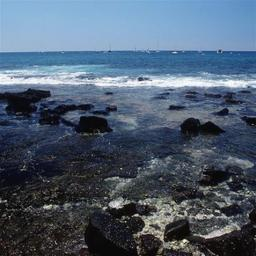

In [9]:
rand_pos = random.randint(0, len(paths))
print('Path: ', paths[rand_pos])
img = cv2.imread(paths[rand_pos])
B, G, R = cv2.split(img)
feature = [np.mean(R), np.mean(G), np.mean(B), np.std(R), np.std(G), np.std(B)]
pred = model.predict([feature])
print('Predicted class: ', le.classes_[pred][0])
cv2_imshow(img)

Matriz de confusión

['coast' 'forest' 'highway']


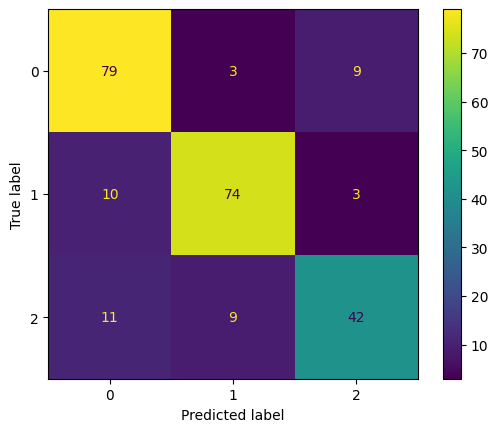

In [10]:
print(le.classes_)
ConfusionMatrixDisplay.from_predictions(testY, predictions)